In [1]:
import numpy as np
import pyvista as pv
pv.start_xvfb()
pv.set_jupyter_backend('static')
import sys
sys.path.append("/local/scratch/groves/jax-forgeRL/models/forging_autoencoder")
from data.dataloaders import GetSingleStepDataLoaders
from utils.plotting import * 
from utils.utils import *

run_name = 'test_comb_FOR_large_2048_p_degx'
dataset_name = run_name + '.npz'
data_path = get_datasets_path() / dataset_name

model_name = run_name + '.pth'
model_path = get_models_path() / model_name


data  = np.load(data_path)
states = data['coords_t']
states_tp1 = data['coords_tp1']
steps = data['steps']
positions = data['positions']
rotations = data['rotations']
# actions = np.hstack((steps, positions, rotations))
# actions = np.hstack((steps, rotations))
actions = np.hstack((steps, positions[:,0].reshape(-1,1), rotations))
# actions = steps

point_size = states.shape[1]
latent_size = 512
batch_size = 32
output_folder = "./output_cogging/"
save_results = True
use_GPU = True
epochs = 201
max_rollout_horizon = 10


In [13]:
states

array([[[ 6.71734338e+00,  1.49094072e+00, -1.73692832e-01],
        [-2.42019874e+00,  1.34740819e+00,  6.65547387e-01],
        [ 6.71739688e+00,  1.40498541e+00, -5.25680286e-01],
        ...,
        [-2.42021329e+00, -7.54243661e-01,  9.36718689e-01],
        [-2.42021329e+00, -1.58371014e-01,  9.51604138e-01],
        [-2.42021329e+00,  2.38233693e-01, -1.22678662e+00]],

       [[ 6.19544859e+00,  1.45622587e+00, -3.31217243e-01],
        [-2.94418585e+00,  1.41168303e+00,  5.15376731e-01],
        [ 6.19550768e+00,  1.33260909e+00, -6.71808418e-01],
        ...,
        [-2.94420040e+00, -6.48122684e-01,  1.01304609e+00],
        [-2.94420040e+00, -5.41544180e-02,  9.63171383e-01],
        [-2.94420040e+00,  1.03678772e-01, -1.24539609e+00]],

       [[ 5.51530424e+00,  1.47304513e+00, -2.44914548e-01],
        [-3.62670144e+00,  1.37851373e+00,  5.98466421e-01],
        [ 5.51527426e+00,  1.37008762e+00, -5.92309351e-01],
        ...,
        [-3.62671599e+00, -7.07256042e-01,

In [2]:
actions.shape

(197988, 3)

Histogram saved! Total parameters: 1,894,533
Weight statistics:
  Mean: 0.439629
  Std: 146.633429
  Min: -1.745446
  Max: 48951.000000


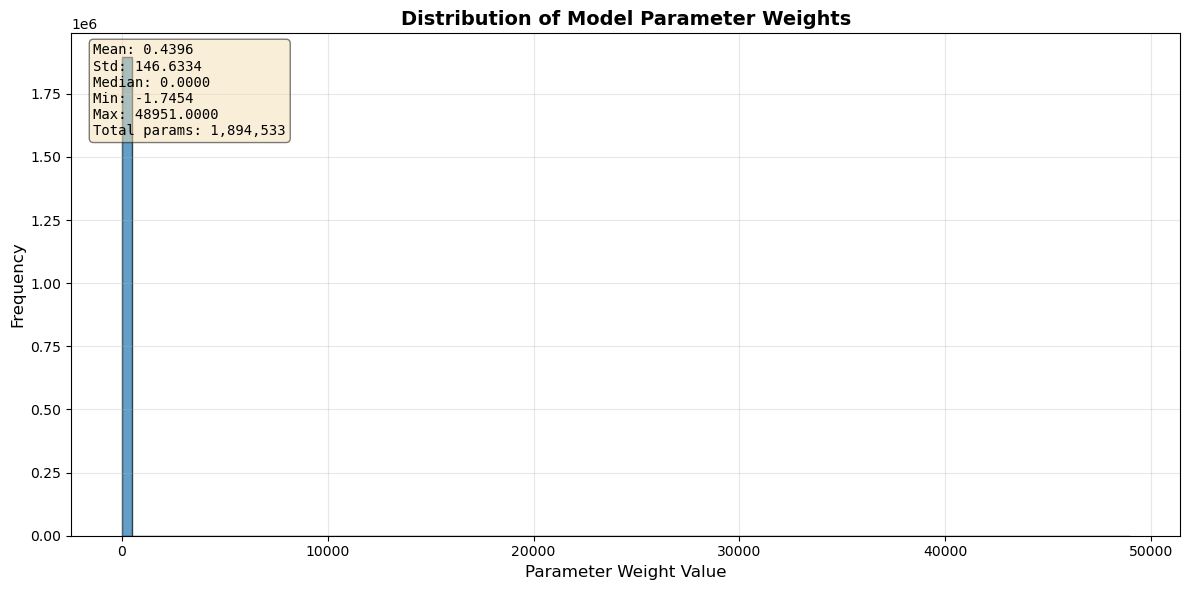

In [9]:
import torch
import model
idx = 25


#IF loading a checkpoint
# model_path = "/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/model/output_cogging/best_model.pth"
# state_dict = torch.load(model_path)['model_state_dict']
#IF Loading a final model
state_dict = torch.load(model_path, weights_only=True)
plot_network_weights(state_dict)

# net = model.PCTransitionModel(point_size, latent_size)
net = model.ResPCTransitionModel(
    point_size=point_size,
    latent_size=latent_size,
    action_dims=actions.shape[-1],
    dropout=0.3    # Can tune 0.2-0.4       
)
net.load_state_dict(state_dict)
net.eval()
x_t = torch.tensor(states[idx], dtype=torch.float32).T.unsqueeze(0) # x.shape = 1,3,n_points
x_tp1 = torch.tensor(states_tp1[idx], dtype=torch.float32).T.unsqueeze(0) # x.shape = 1,3,n_points

a = torch.tensor(actions[idx], dtype=torch.float32).unsqueeze(0) #a.shape = 1,8
x_t_np = x_t.T.squeeze().numpy()
x_tp1_np = x_tp1.T.squeeze().numpy()
detla_gt = x_tp1 - x_t

# visualize_point_cloud(c_t[25],a=-p[25], point_size=5)
# compare_scatters(pc1=x_t_np, pc2=x_tp1_np, label_1="Original Mesh", label_2="Deformed Mesh")
# visualize_vector_diff(mesh1=None,mesh2=None, pc1=x_t_np,pc2=x_tp1_np)


# pl = pv.Plotter()
# p = pv.PolyData(x_t_np)
# pl.add_mesh(p)
# pl.show()

In [10]:
# a = torch.tensor([0.5])

def forward(x,a):
    with torch.no_grad():
        return(net(x_t=x,a_t=a))

t = 1
for _ in range(t):

    delta_hat = forward(x_t, a) / 100
    x_tp1_hat = x_t.squeeze(0).T + delta_hat.squeeze(0)

x_tp1_hat = x_tp1_hat.numpy()
delta_hat = delta_hat.squeeze(0).T
delta_gt = x_tp1 - x_t

loss_cont = torch.sum(((delta_hat - delta_gt) ** 2),axis=1).numpy()
print(loss_cont)



[[6.1116396e-03 2.8173782e-13 6.5683681e-03 ... 8.2580595e-11
  9.6316577e-14 2.0234445e-10]]


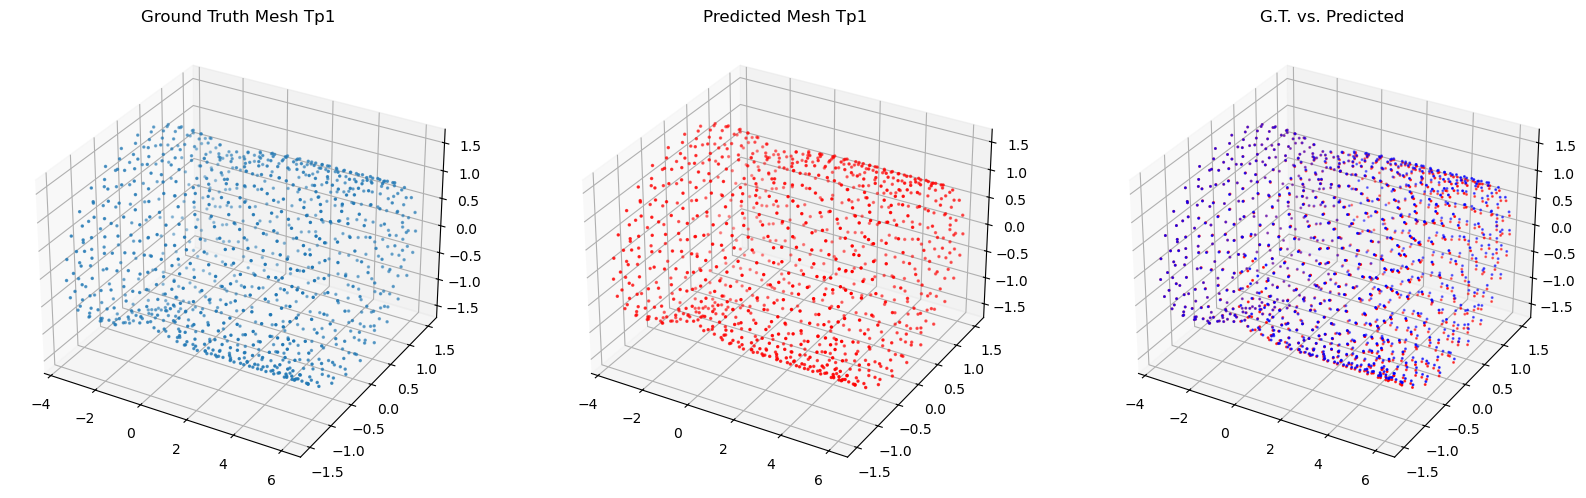

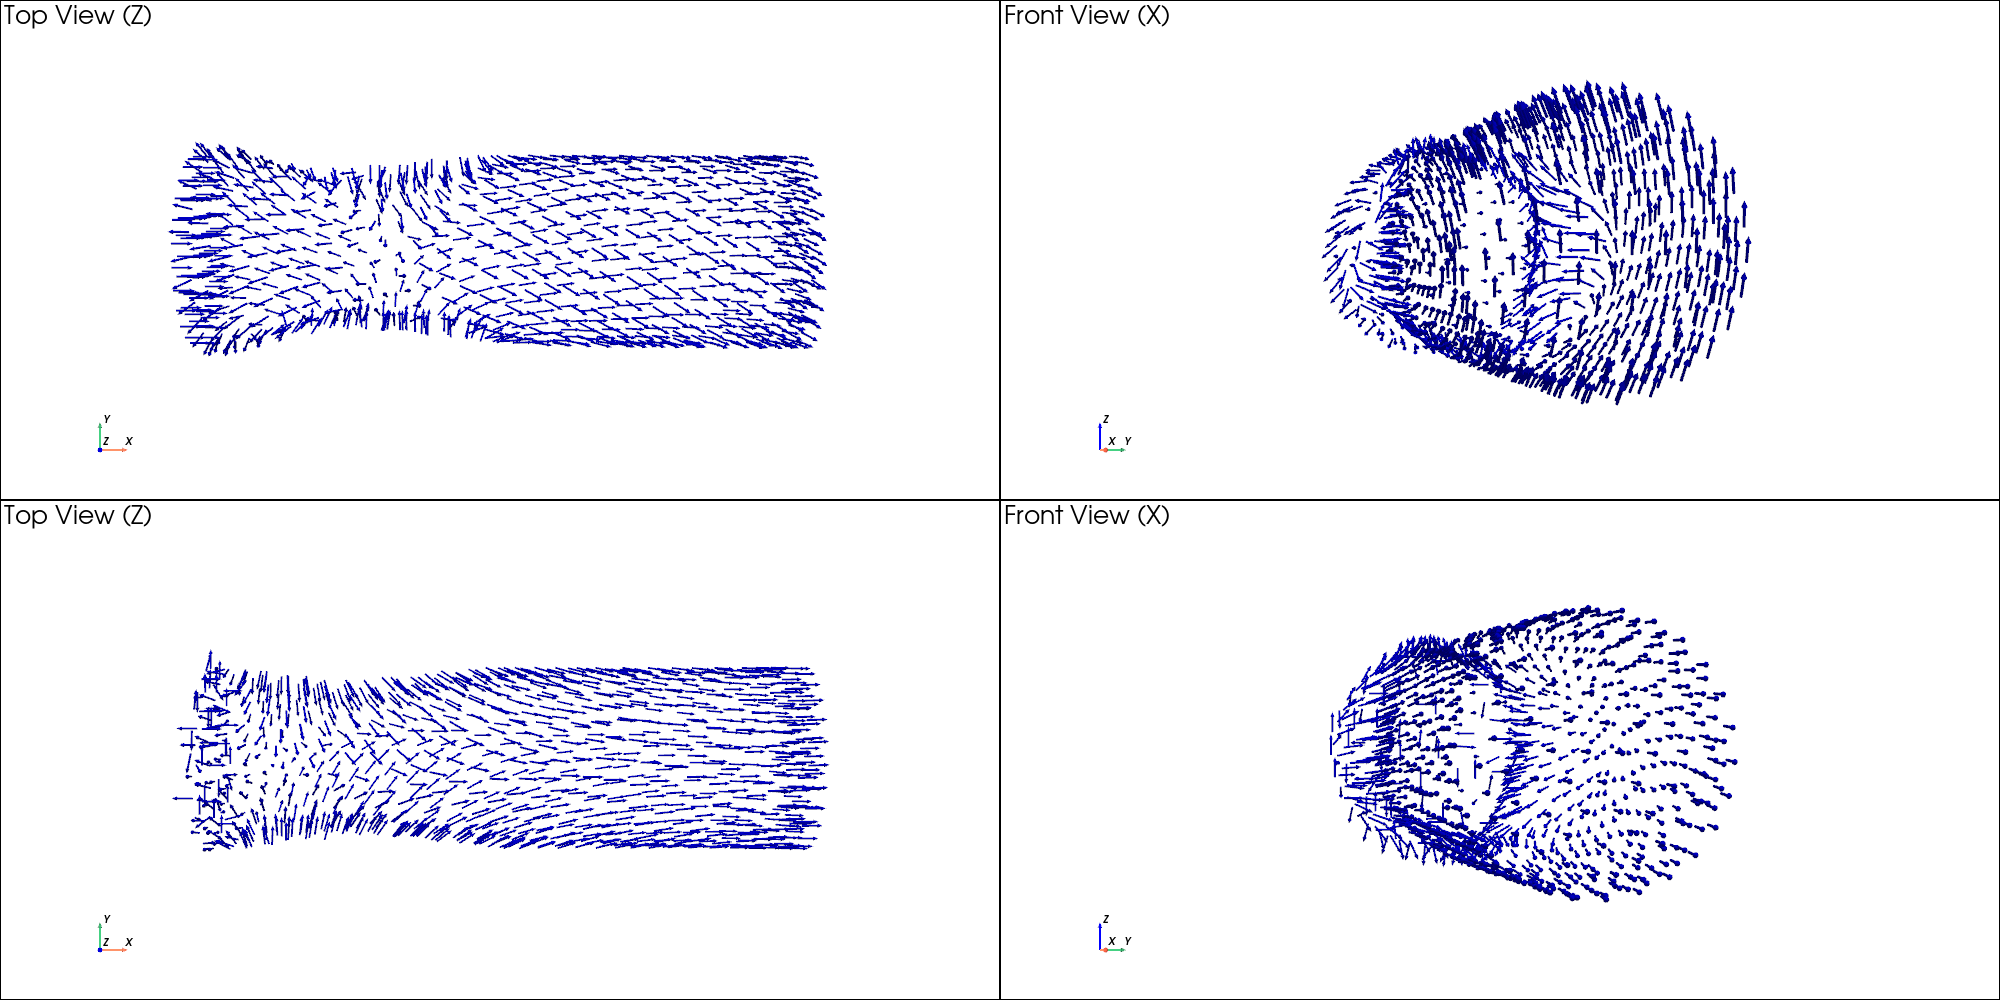

In [11]:
compare_scatters(pc1=x_tp1_np, pc2=x_tp1_hat, 
                 label_1="Ground Truth Mesh Tp1", 
                 label_2="Predicted Mesh Tp1", 
                 label_3='G.T. vs. Predicted')

visualize_point_diff(x_tp1_hat,x_tp1_np, point_size=5, label="Vector Field Error \n(Predicted Deltas minus G.T. Deltas)") # shows networks bias

compare_vector_fields(x_t_np, x_tp1_np, x_tp1_hat, min_magnitude=8.0)

/local/scratch/groves/jax-forgeRL/models/forging_autoencoder/utils/plotting.py:122: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


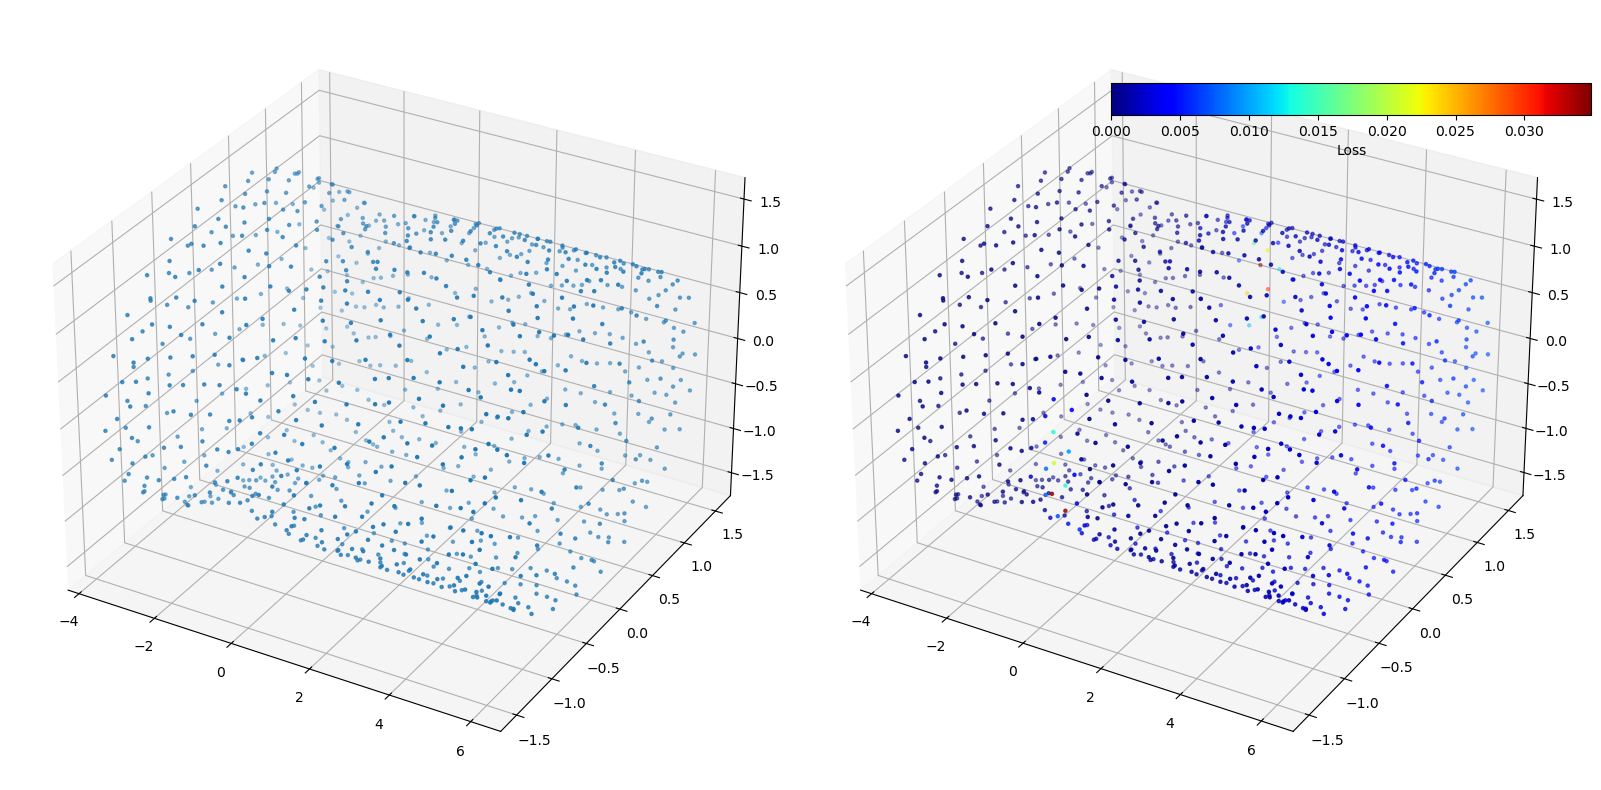

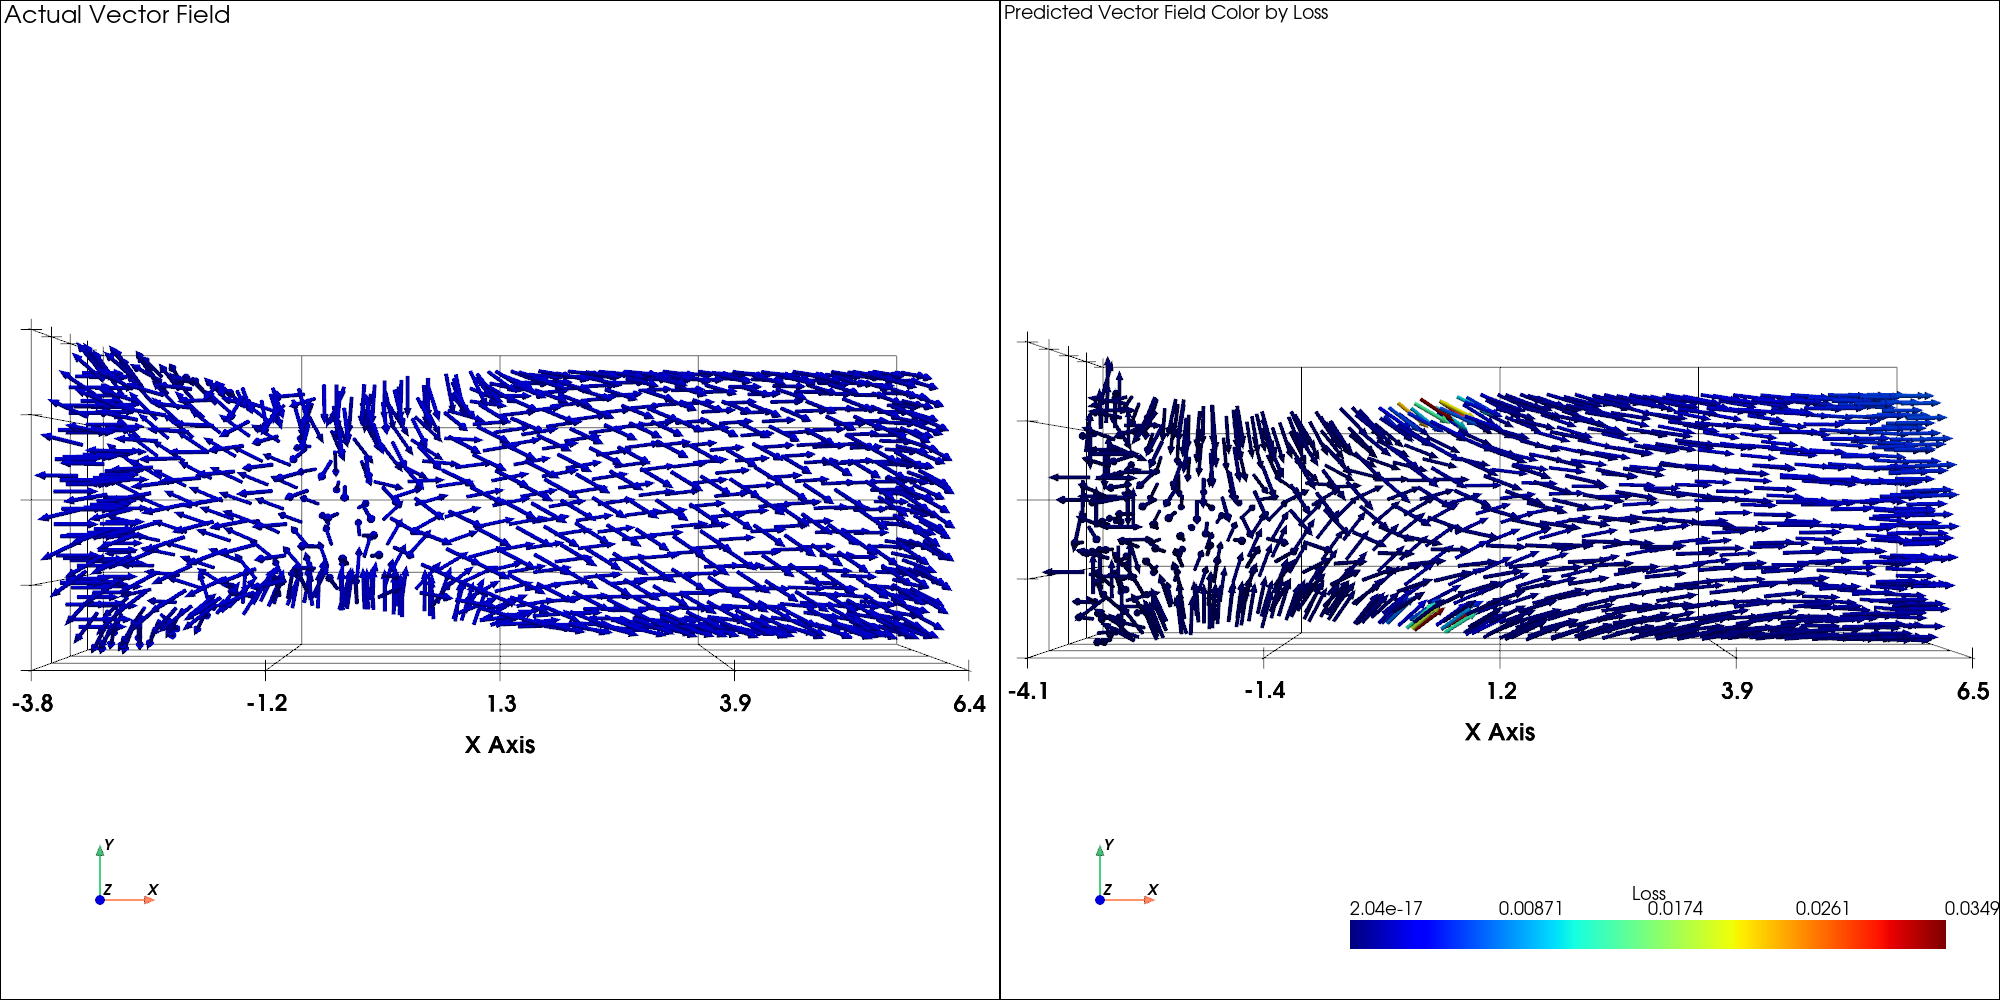

In [12]:
compare_scatters_w_loss_cont(pc1=x_t_np, pc2=x_tp1_hat, loss_cont=loss_cont)
visualize_vector_diff_w_loss_cont(x_t=x_t_np, x_tp1=x_tp1_np, x_hat=x_tp1_hat, loss_cont=loss_cont[-1], min_magnitude=8.0)